In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/everest/sv1_perexp_lrg.fits'))
cat['EFFTIME_ELG'] = 8.60 * cat['TSNR2_ELG']
cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove QSO targets
mask = cat['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# mask = cat['EFFTIME_DARK_GFA']!=0
# print('EFFTIME_GFA', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
# cat = cat[mask]

# # Require a minimum depth
# min_depth = 500.
# mask = cat['EFFTIME_LRG']>min_depth
# print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# cat = cat[mask]

# Julien's bad fibers list
bad_fibers = np.array(Table.read('/Users/rongpu/Documents/Data/desi_data/everest/misc/badfibers.csv')['FIBER'])
bad_fibers = np.append(bad_fibers, np.arange(2663, 2674+1))  # fibers affected by the CCD z5 defect
bad_fibers = np.append(bad_fibers, [3402, 3429])  # "swapped" fibers
bad_fibers = np.unique(bad_fibers)
print(len(bad_fibers))
mask_bad = np.in1d(cat['FIBER'], bad_fibers)
print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
cat = cat[~mask_bad]
print(len(cat))

FIBERSTATUS 414186 91655 0.18119329987090804
No data 414186 0 0.0
LRG mask 371619 42567 0.10277266735234894
Remove QSO targets 360700 10919 0.029382243642009694
199
Bad fibers 346572 14128 0.039168283892431384
346572


In [4]:
cat_1x = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/everest/sv1_1x_depth_lrg.fits'))
cat_1x['EFFTIME_ELG'] = 8.60 * cat_1x['TSNR2_ELG']
cat_1x['EFFTIME_LRG'] = 12.15 * cat_1x['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat_1x['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Remove "no data" fibers
mask = cat_1x['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Apply LRG mask
mask = cat_1x['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Remove QSO targets
mask = cat_1x['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# mask = cat_1x['EFFTIME_DARK_GFA']!=0
# print('EFFTIME_GFA', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
# cat_1x = cat_1x[mask]

# # Require a minimum depth
# min_depth = 500.
# mask = cat_1x['EFFTIME_LRG']>min_depth
# print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# cat_1x = cat_1x[mask]

# Julien's bad fibers list
bad_fibers = np.array(Table.read('/Users/rongpu/Documents/Data/desi_data/everest/misc/badfibers.csv')['FIBER'])
bad_fibers = np.append(bad_fibers, np.arange(2663, 2674+1))  # fibers affected by the CCD z5 defect
bad_fibers = np.append(bad_fibers, [3402, 3429])  # "swapped" fibers
bad_fibers = np.unique(bad_fibers)
print(len(bad_fibers))
mask_bad = np.in1d(cat_1x['FIBER'], bad_fibers)
print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
cat_1x = cat_1x[~mask_bad]
print(len(cat_1x))

FIBERSTATUS 27179 4874 0.15206064954918416
No data 27179 0 0.0
LRG mask 25072 2107 0.07752308767798669
Remove QSO targets 24557 515 0.020540842373962986
199
Bad fibers 23663 894 0.03640509834263143
23663


In [5]:
columns = list(np.intersect1d(cat.colnames, cat_1x.colnames))
cat = cat[columns]
cat_1x = cat_1x[columns]

cat = vstack([cat, cat_1x])

In [6]:
deep = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/everest/sv1_cumulative_lrg.fits'))
deep['EFFTIME_ELG'] = 8.60 * deep['TSNR2_ELG']
deep['EFFTIME_LRG'] = 12.15 * deep['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = deep['COADD_FIBERSTATUS']==0
print('COADD_FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

mask = deep['ZWARN']==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Apply LRG mask
mask = deep['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove QSO targets
mask = deep['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Require a minimum depth
min_depth = 3000.
mask = deep['EFFTIME_LRG']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
deep = deep[mask]

# Julien's bad fibers list
bad_fibers = np.array(Table.read('/Users/rongpu/Documents/Data/desi_data/everest/misc/badfibers.csv')['FIBER'])
bad_fibers = np.append(bad_fibers, np.arange(2663, 2674+1))  # fibers affected by the CCD z5 defect
bad_fibers = np.append(bad_fibers, [3402, 3429])  # "swapped" fibers
bad_fibers = np.unique(bad_fibers)
print(len(bad_fibers))
mask_bad = np.in1d(deep['FIBER'], bad_fibers)
print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
deep = deep[~mask_bad]
print(len(deep), len(np.unique(deep['TARGETID'])))

# Remove duplidates keeping the higher EFFTIME objects
deep.sort('EFFTIME_LRG', reverse=True)
_, idx_keep = np.unique(deep['TARGETID'], return_index=True)
deep = deep[idx_keep]
print(len(deep), len(np.unique(deep['TARGETID'])))

# Custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*deep['Z']))
mask_remove = (d>30) & (deep['DELTACHI2']<30)
mask_remove |= (d<30) & (deep['DELTACHI2']<d)
mask_remove |= (deep['DELTACHI2']<10)
mask_quality_deep = deep['ZWARN']==0
mask_quality_deep &= deep['Z']<1.4
mask_quality_deep &= (~mask_remove)
print(np.sum(~mask_quality_deep))
deep = deep[mask_quality_deep]

deep_columns_old = ['TARGETID', 'Z', 'ZERR', 'ZWARN', 'SPECTYPE', 'DELTACHI2', 'EFFTIME_LRG', 'EFFTIME_ELG']
deep_columns_new = ['TARGETID', 'Z_deep', 'ZERR_deep', 'ZWARN_deep', 'SPECTYPE_deep', 'DELTACHI2_deep', 'EFFTIME_LRG_deep', 'EFFTIME_ELG_deep']
deep.rename_columns(deep_columns_old, deep_columns_new)

cat = join(cat, deep[deep_columns_new], keys='TARGETID')

COADD_FIBERSTATUS 46403 8832 0.15989861500859961
No data 45392 1011 0.021787384436351098
LRG mask 41301 4091 0.09012601339443074
Remove QSO targets 39607 1694 0.041015956030120336
Min depth 30657 8950 0.7740298432095337
199
Bad fibers 29459 1198 0.03907753531004338
29459 29417
29417 29417
230


---------

In [7]:
# Catastrophic redshift failures
zdiff_threshold = 0.0033
mask_fail = np.abs((cat['Z'] - cat['Z_deep'])/(1 + cat['Z_deep'])) > zdiff_threshold
print(np.sum(mask_fail), np.sum(mask_fail)/len(mask_fail))
# Also reject objects with ZWARN!=0 or z>1.4 or DELTACHI2<15 in the deep coadds
mask_deep = (cat['ZWARN_deep']==0) & (cat['Z_deep']<1.4)
mask_deep_fail = ~mask_deep
# mask_deep = (cat['ZWARN_deep']==0) & (cat['Z_deep']<1.4) & (cat['DELTACHI2_deep']>30)
mask_fail |= mask_deep_fail
print(np.sum(mask_fail), np.sum(mask_fail)/len(mask_fail))
print()

mask = cat['main_lrg'].copy()
print(np.sum(mask_fail & mask), np.sum(mask_fail & mask)/np.sum(mask))
mask &= cat['EFFTIME_LRG']>800
print(np.sum(mask_fail & mask), np.sum(mask_fail & mask)/np.sum(mask))

73386 0.2255983030787439
73386 0.2255983030787439

12094 0.13385870347209156
184 0.01119221411192214


In [8]:
# mask_quality = cat['ZWARN']==0
# mask_quality &= cat['Z']<1.4
# mask_quality &= cat['DELTACHI2']>15

# Custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*cat['Z']))
mask_remove = (d>30) & (cat['DELTACHI2']<30)
mask_remove |= (d<30) & (cat['DELTACHI2']<d)
mask_remove |= (cat['DELTACHI2']<10)
mask_quality = cat['ZWARN']==0
mask_quality &= cat['Z']<1.4
mask_quality &= (~mask_remove)

print(np.sum((~mask_quality)), np.sum((~mask_quality))/len((~mask_quality)))
mask = cat['EFFTIME_LRG']>800
# Failures in "good redshifts"
print(np.sum(mask_fail & mask_quality & mask), np.sum(mask_fail & mask_quality & mask)/np.sum(mask_quality & mask))
print()

mask = cat['main_lrg'].copy()
print(np.sum((~mask_quality) & mask), np.sum((~mask_quality) & mask)/np.sum(mask))
mask &= cat['EFFTIME_LRG']>800
# Failures in "good redshifts"
print(np.sum(mask_fail & mask_quality & mask), np.sum(mask_fail & mask_quality & mask)/np.sum(mask_quality & mask))

95016 0.29209179360272985
386 0.007030453154597115

15900 0.17598423889583725
48 0.002958215210156539


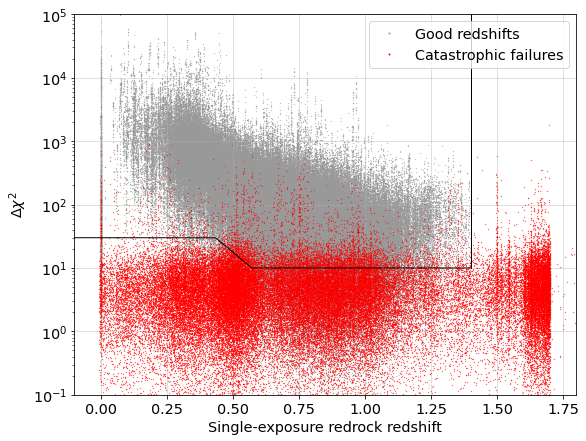

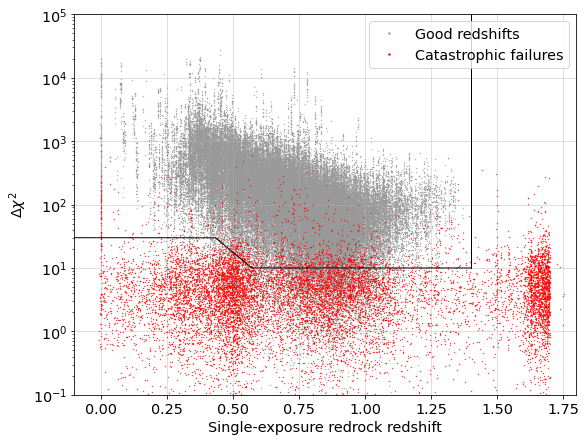

In [9]:
x = np.linspace(-1, 1.4, 10000)
y = np.ones_like(x)
y = (10**(3 - 3.5*x))
y[y<10] = 10
y[y>30] = 30

y1 = np.linspace(10, 1e6)
x1 = np.ones_like(y1) * 1.4

mask = np.full(len(cat), True)
plt.figure(figsize=(9, 7))
plt.plot(cat['Z'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=0.5, alpha=1, label='Good redshifts', zorder=1)
plt.plot(cat['Z'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'r.', ms=0.5, alpha=1, label='Catastrophic failures', zorder=2)
plt.plot(x, y, color='k', lw=1)
plt.plot(x1, y1, color='k', lw=1)
# plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('Single-exposure redrock redshift')
plt.ylabel('$\Delta \chi^2$')
plt.axis([-0.1, 1.8, .1, 100000])
plt.legend(markerscale=4, loc='upper right')
plt.grid(alpha=0.5)
plt.show()

mask = cat['main_lrg'].copy()
plt.figure(figsize=(9, 7))
plt.plot(cat['Z'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=0.7, alpha=1, label='Good redshifts', zorder=1)
plt.plot(cat['Z'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'r.', ms=0.7, alpha=1, label='Catastrophic failures', zorder=2)
plt.plot(x, y, color='k', lw=1)
plt.plot(x1, y1, color='k', lw=1)
# plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('Single-exposure redrock redshift')
plt.ylabel('$\Delta \chi^2$')
plt.axis([-0.1, 1.8, .1, 100000])
plt.legend(markerscale=4, loc='upper right')
plt.grid(alpha=0.5)
plt.show()

In [10]:
cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']

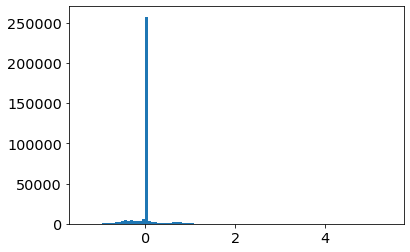

In [11]:
plt.hist(cat['Z']-cat['Z_deep'], 100);

In [12]:
cat_all = cat.copy()

--------

In [13]:
cat = cat[cat['main_lrg']]
print(len(cat))

90349


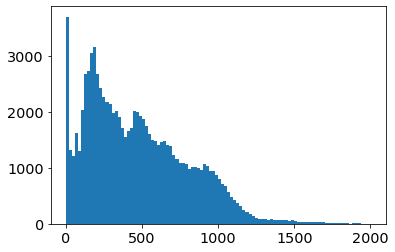

In [14]:
plt.hist(cat['EFFTIME_LRG'], 100, range=(0, 2000));

In [15]:
mask = (cat['EFFTIME_LRG']>800) & (cat['EFFTIME_LRG']<1400)
cat = cat[mask]
print(len(cat))

15625


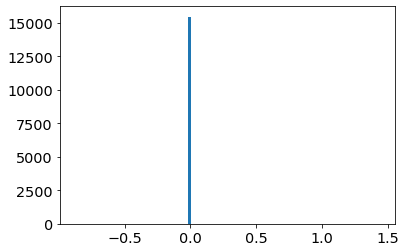

In [16]:
plt.hist(cat['Z']-cat['Z_deep'], 100);

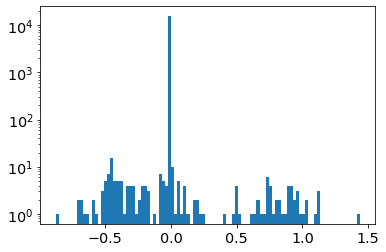

In [17]:
plt.hist(cat['Z']-cat['Z_deep'], 100, log=True);

In [18]:
# Custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*cat['Z']))
mask_remove = (d>30) & (cat['DELTACHI2']<30)
mask_remove |= (d<30) & (cat['DELTACHI2']<d)
mask_remove |= (cat['DELTACHI2']<10)
mask_quality = cat['ZWARN']==0
mask_quality &= cat['Z']<1.4
mask_quality &= (~mask_remove)

print(np.sum((~mask_quality)), np.sum((~mask_quality))/len((~mask_quality)))

212 0.013568


In [19]:
cat = cat[mask_quality]
print(len(cat))

15413


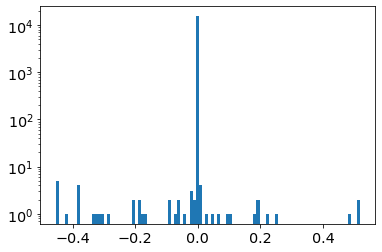

In [20]:
plt.hist(cat['Z']-cat['Z_deep'], 100, log=True);

In [21]:
mask_fail = np.abs((cat['Z'] - cat['Z_deep'])/(1 + cat['Z_deep'])) > zdiff_threshold
print(np.sum(mask_fail))
cat = cat[~mask_fail]

46


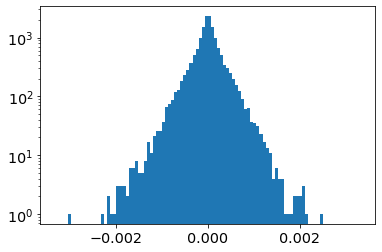

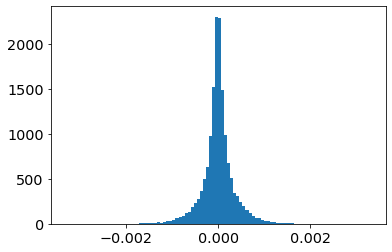

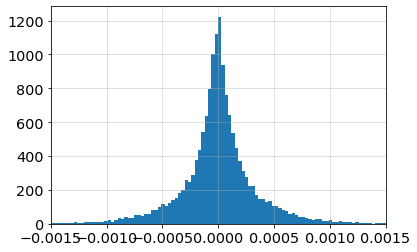

In [22]:
plt.hist(cat['Z']-cat['Z_deep'], 100, log=True, range=(-0.0033, 0.0033))
plt.show()

plt.hist(cat['Z']-cat['Z_deep'], 100, log=False, range=(-0.0033, 0.0033))
plt.show()

plt.hist(cat['Z']-cat['Z_deep'], 100, log=False, range=(-0.0015, 0.0015))
plt.xlim(-0.0015, 0.0015)
plt.grid(alpha=0.5)
plt.show()

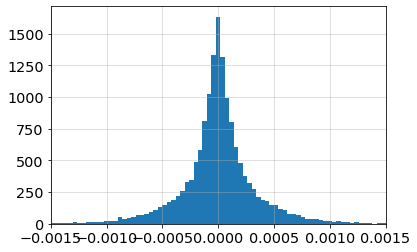

In [23]:
bins = np.linspace(-0.0015, 0.0015, 76)
plt.hist(cat['Z']-cat['Z_deep'], log=False, bins=bins)
plt.xlim(-0.0015, 0.0015)
plt.grid(alpha=0.5)
plt.show()

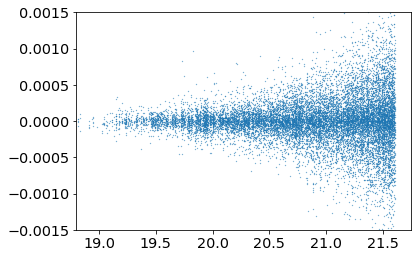

In [24]:
plt.plot(cat['zfibermag'], cat['Z']-cat['Z_deep'], '.', ms=0.5)
plt.axis([18.8, 21.75, -0.0015, 0.0015])
plt.show()

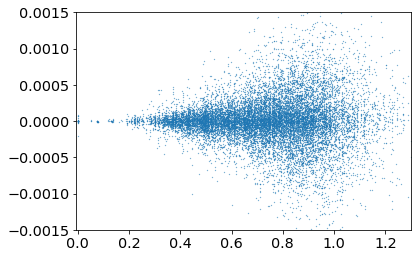

In [25]:
plt.plot(cat['Z'], cat['Z']-cat['Z_deep'], '.', ms=0.5)
plt.axis([-0.005, 1.3, -0.0015, 0.0015])
plt.show()

In [26]:
from scipy.optimize import curve_fit
from scipy.stats import norm
from scipy.stats import cauchy

def cauchy_cdf(x, scale):
    return cauchy.cdf(x, scale=scale)

def norm_cdf(x, scale):
    return norm.cdf(x, scale=scale)

-------

0.00014487319494556426
6.089063709215547e-05


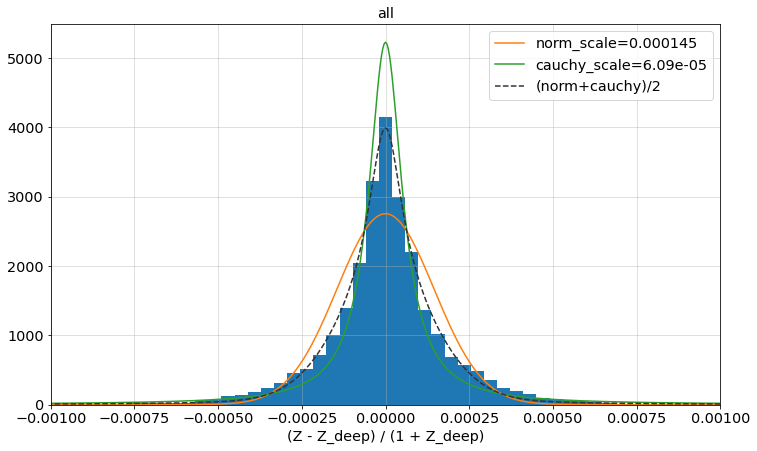

In [78]:
# dz = ((cat['Z']-cat['Z_deep']))[mask]
dz = ((cat['Z']-cat['Z_deep'])/(1+cat['Z_deep']))

bins_cdf = np.linspace(-0.002, 0.002, 1000)
bin_centers_cdf = (bins_cdf[1:] + bins_cdf[:-1])/2

count, _ =np.histogram(dz, bins=bins_cdf)
cdf = np.cumsum(count)
cdf = cdf/cdf.max()

popt = curve_fit(norm_cdf, bin_centers_cdf, cdf, p0=0.0004)
norm_scale = popt[0][0]
print(norm_scale)

popt = curve_fit(cauchy_cdf, bin_centers_cdf, cdf, p0=0.0002)
cauchy_scale = popt[0][0]
print(cauchy_scale)

# plt.figure(figsize=(12, 7))
# plt.plot(bin_centers_cdf, cdf)
# plt.plot(bin_centers_cdf, norm.cdf(bin_centers_cdf, scale=norm_scale), '--')
# plt.plot(bin_centers_cdf, cauchy.cdf(bin_centers_cdf, scale=cauchy_scale), '--')
# plt.grid(alpha=0.5)
# plt.show()

bins = np.linspace(-0.001, 0.001, 52)
plt.figure(figsize=(12, 7))
plt.hist(dz, log=False, bins=bins, density=True)
plt.xlabel('(Z - Z_deep) / (1 + Z_deep)')
plt.plot(bin_centers_cdf, norm.pdf(bin_centers_cdf, scale=norm_scale), label='norm_scale={:.3g}'.format(norm_scale))
plt.plot(bin_centers_cdf, cauchy.pdf(bin_centers_cdf, scale=cauchy_scale), label='cauchy_scale={:.3g}'.format(cauchy_scale))
plt.plot(bin_centers_cdf, (norm.pdf(bin_centers_cdf, scale=norm_scale)+cauchy.pdf(bin_centers_cdf, scale=cauchy_scale))/2, label='(norm+cauchy)/2'.format(cauchy_scale), ls='--', color='0.2')
plt.title('all')
plt.xlim(-0.001, 0.001)
plt.grid(alpha=0.5)
plt.legend()
plt.show()

8.086502466282872e-05
3.394182610259445e-05


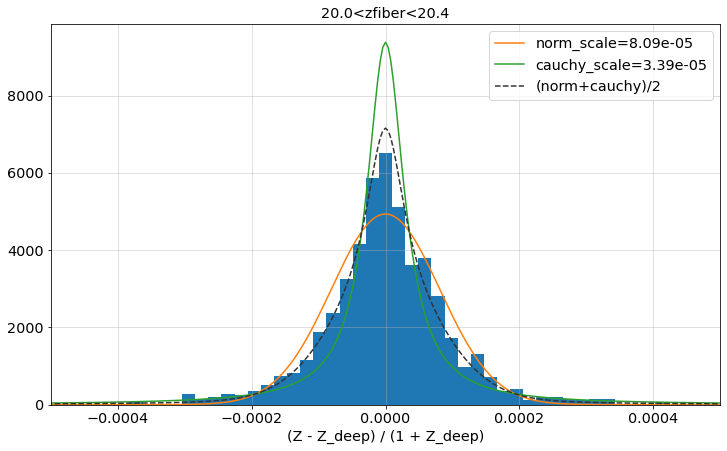

In [79]:
mask = (cat['zfibermag']>20) & (cat['zfibermag']<20.4)
# dz = ((cat['Z']-cat['Z_deep']))[mask]
dz = ((cat['Z']-cat['Z_deep'])/(1+cat['Z_deep']))[mask]

bins_cdf = np.linspace(-0.002, 0.002, 1000)
bin_centers_cdf = (bins_cdf[1:] + bins_cdf[:-1])/2

count, _ =np.histogram(dz, bins=bins_cdf)
cdf = np.cumsum(count)
cdf = cdf/cdf.max()

popt = curve_fit(norm_cdf, bin_centers_cdf, cdf, p0=0.0004)
norm_scale = popt[0][0]
print(norm_scale)

popt = curve_fit(cauchy_cdf, bin_centers_cdf, cdf, p0=0.0002)
cauchy_scale = popt[0][0]
print(cauchy_scale)

# plt.figure(figsize=(12, 7))
# plt.plot(bin_centers_cdf, cdf)
# plt.plot(bin_centers_cdf, norm.cdf(bin_centers_cdf, scale=norm_scale), '--')
# plt.plot(bin_centers_cdf, cauchy.cdf(bin_centers_cdf, scale=cauchy_scale), '--')
# plt.grid(alpha=0.5)
# plt.show()

bins = np.linspace(-0.0005, 0.0005, 52)
plt.figure(figsize=(12, 7))
plt.hist(dz, log=False, bins=bins, density=True)
plt.xlabel('(Z - Z_deep) / (1 + Z_deep)')
plt.plot(bin_centers_cdf, norm.pdf(bin_centers_cdf, scale=norm_scale), label='norm_scale={:.3g}'.format(norm_scale))
plt.plot(bin_centers_cdf, cauchy.pdf(bin_centers_cdf, scale=cauchy_scale), label='cauchy_scale={:.3g}'.format(cauchy_scale))
plt.plot(bin_centers_cdf, (norm.pdf(bin_centers_cdf, scale=norm_scale)+cauchy.pdf(bin_centers_cdf, scale=cauchy_scale))/2, label='(norm+cauchy)/2'.format(cauchy_scale), ls='--', color='0.2')
plt.title('20.0<zfiber<20.4')
plt.xlim(-0.0005, 0.0005)
plt.grid(alpha=0.5)
plt.legend()
plt.show()

0.00015994072043628112
6.74770330070546e-05


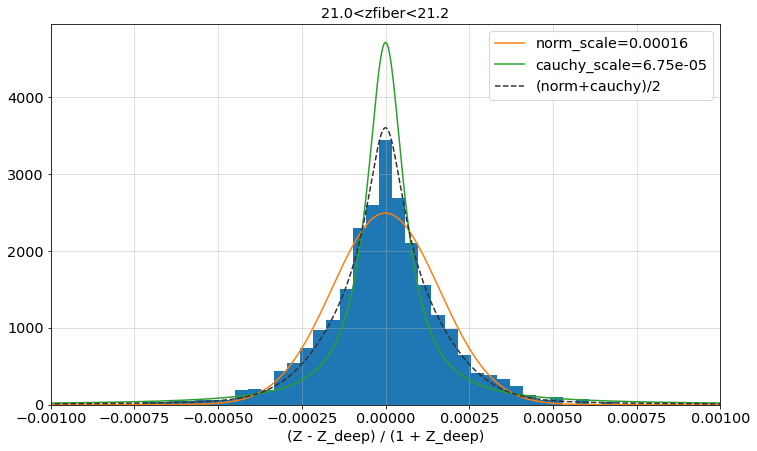

In [80]:
mask = (cat['zfibermag']>21) & (cat['zfibermag']<21.2)
# dz = ((cat['Z']-cat['Z_deep']))[mask]
dz = ((cat['Z']-cat['Z_deep'])/(1+cat['Z_deep']))[mask]

bins_cdf = np.linspace(-0.002, 0.002, 1000)
bin_centers_cdf = (bins_cdf[1:] + bins_cdf[:-1])/2

count, _ =np.histogram(dz, bins=bins_cdf)
cdf = np.cumsum(count)
cdf = cdf/cdf.max()

popt = curve_fit(norm_cdf, bin_centers_cdf, cdf, p0=0.0004)
norm_scale = popt[0][0]
print(norm_scale)

popt = curve_fit(cauchy_cdf, bin_centers_cdf, cdf, p0=0.0002)
cauchy_scale = popt[0][0]
print(cauchy_scale)

# plt.figure(figsize=(12, 7))
# plt.plot(bin_centers_cdf, cdf)
# plt.plot(bin_centers_cdf, norm.cdf(bin_centers_cdf, scale=norm_scale), '--')
# plt.plot(bin_centers_cdf, cauchy.cdf(bin_centers_cdf, scale=cauchy_scale), '--')
# plt.grid(alpha=0.5)
# plt.show()

bins = np.linspace(-0.001, 0.001, 52)
plt.figure(figsize=(12, 7))
plt.hist(dz, log=False, bins=bins, density=True)
plt.xlabel('(Z - Z_deep) / (1 + Z_deep)')
plt.plot(bin_centers_cdf, norm.pdf(bin_centers_cdf, scale=norm_scale), label='norm_scale={:.3g}'.format(norm_scale))
plt.plot(bin_centers_cdf, cauchy.pdf(bin_centers_cdf, scale=cauchy_scale), label='cauchy_scale={:.3g}'.format(cauchy_scale))
plt.plot(bin_centers_cdf, (norm.pdf(bin_centers_cdf, scale=norm_scale)+cauchy.pdf(bin_centers_cdf, scale=cauchy_scale))/2, label='(norm+cauchy)/2'.format(cauchy_scale), ls='--', color='0.2')
plt.title('21.0<zfiber<21.2')
plt.xlim(-0.001, 0.001)
plt.grid(alpha=0.5)
plt.legend()
plt.show()

0.00023196171814514492
9.875593783830337e-05


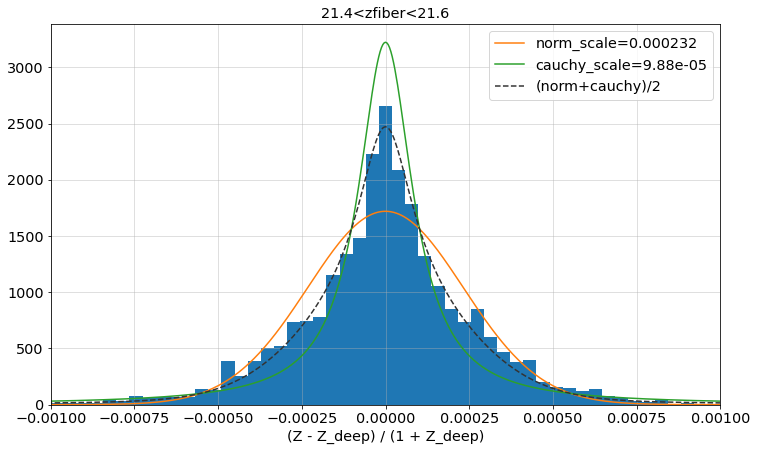

In [81]:
mask = (cat['zfibermag']>21.4) & (cat['zfibermag']<21.6)
# dz = ((cat['Z']-cat['Z_deep']))[mask]
dz = ((cat['Z']-cat['Z_deep'])/(1+cat['Z_deep']))[mask]

bins_cdf = np.linspace(-0.002, 0.002, 1000)
bin_centers_cdf = (bins_cdf[1:] + bins_cdf[:-1])/2

count, _ =np.histogram(dz, bins=bins_cdf)
cdf = np.cumsum(count)
cdf = cdf/cdf.max()

popt = curve_fit(norm_cdf, bin_centers_cdf, cdf, p0=0.0004)
norm_scale = popt[0][0]
print(norm_scale)

popt = curve_fit(cauchy_cdf, bin_centers_cdf, cdf, p0=0.0002)
cauchy_scale = popt[0][0]
print(cauchy_scale)

# plt.figure(figsize=(12, 7))
# plt.plot(bin_centers_cdf, cdf)
# plt.plot(bin_centers_cdf, norm.cdf(bin_centers_cdf, scale=norm_scale), '--')
# plt.plot(bin_centers_cdf, cauchy.cdf(bin_centers_cdf, scale=cauchy_scale), '--')
# plt.grid(alpha=0.5)
# plt.show()

bins = np.linspace(-0.001, 0.001, 52)
plt.figure(figsize=(12, 7))
plt.hist(dz, log=False, bins=bins, density=True)
plt.xlabel('(Z - Z_deep) / (1 + Z_deep)')
plt.plot(bin_centers_cdf, norm.pdf(bin_centers_cdf, scale=norm_scale), label='norm_scale={:.3g}'.format(norm_scale))
plt.plot(bin_centers_cdf, cauchy.pdf(bin_centers_cdf, scale=cauchy_scale), label='cauchy_scale={:.3g}'.format(cauchy_scale))
plt.plot(bin_centers_cdf, (norm.pdf(bin_centers_cdf, scale=norm_scale)+cauchy.pdf(bin_centers_cdf, scale=cauchy_scale))/2, label='(norm+cauchy)/2'.format(cauchy_scale), ls='--', color='0.2')
plt.title('21.4<zfiber<21.6')
plt.xlim(-0.001, 0.001)
plt.grid(alpha=0.5)
plt.legend()
plt.show()

-----

0.0001014204833099774
4.289084194118856e-05


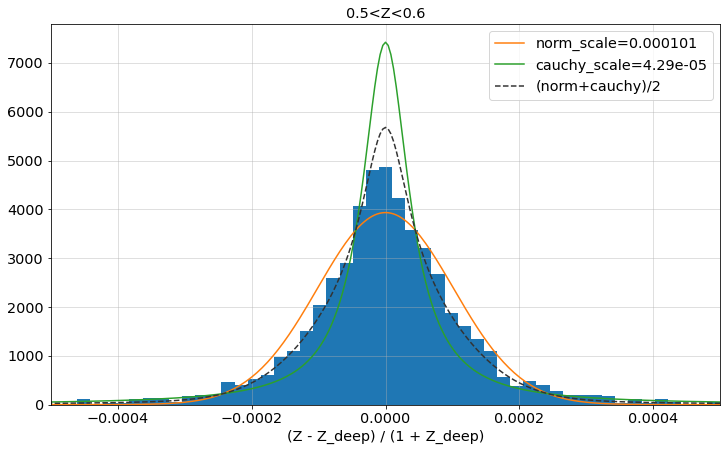

In [93]:
mask = (cat['Z']>0.5) & (cat['Z']<0.6)
# dz = ((cat['Z']-cat['Z_deep']))[mask]
dz = ((cat['Z']-cat['Z_deep'])/(1+cat['Z_deep']))[mask]

bins_cdf = np.linspace(-0.002, 0.002, 1000)
bin_centers_cdf = (bins_cdf[1:] + bins_cdf[:-1])/2

count, _ =np.histogram(dz, bins=bins_cdf)
cdf = np.cumsum(count)
cdf = cdf/cdf.max()

popt = curve_fit(norm_cdf, bin_centers_cdf, cdf, p0=0.0004)
norm_scale = popt[0][0]
print(norm_scale)

popt = curve_fit(cauchy_cdf, bin_centers_cdf, cdf, p0=0.0002)
cauchy_scale = popt[0][0]
print(cauchy_scale)

# plt.figure(figsize=(12, 7))
# plt.plot(bin_centers_cdf, cdf)
# plt.plot(bin_centers_cdf, norm.cdf(bin_centers_cdf, scale=norm_scale), '--')
# plt.plot(bin_centers_cdf, cauchy.cdf(bin_centers_cdf, scale=cauchy_scale), '--')
# plt.grid(alpha=0.5)
# plt.show()

bins = np.linspace(-0.0005, 0.0005, 52)
plt.figure(figsize=(12, 7))
plt.hist(dz, log=False, bins=bins, density=True)
plt.xlabel('(Z - Z_deep) / (1 + Z_deep)')
plt.plot(bin_centers_cdf, norm.pdf(bin_centers_cdf, scale=norm_scale), label='norm_scale={:.3g}'.format(norm_scale))
plt.plot(bin_centers_cdf, cauchy.pdf(bin_centers_cdf, scale=cauchy_scale), label='cauchy_scale={:.3g}'.format(cauchy_scale))
plt.plot(bin_centers_cdf, (norm.pdf(bin_centers_cdf, scale=norm_scale)+cauchy.pdf(bin_centers_cdf, scale=cauchy_scale))/2, label='(norm+cauchy)/2'.format(cauchy_scale), ls='--', color='0.2')
plt.title('0.5<Z<0.6')
plt.xlim(-0.0005, 0.0005)
plt.grid(alpha=0.5)
plt.legend()
plt.show()

0.0001958900482017687
8.257721052445856e-05


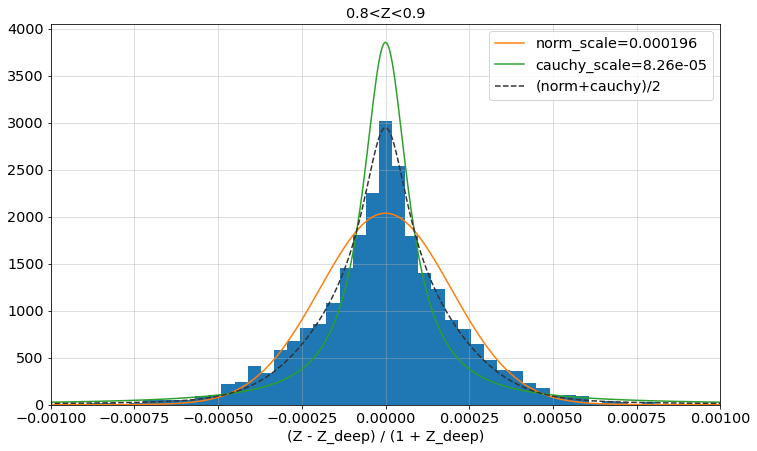

In [95]:
mask = (cat['Z']>0.8) & (cat['Z']<0.9)
# dz = ((cat['Z']-cat['Z_deep']))[mask]
dz = ((cat['Z']-cat['Z_deep'])/(1+cat['Z_deep']))[mask]

bins_cdf = np.linspace(-0.002, 0.002, 1000)
bin_centers_cdf = (bins_cdf[1:] + bins_cdf[:-1])/2

count, _ =np.histogram(dz, bins=bins_cdf)
cdf = np.cumsum(count)
cdf = cdf/cdf.max()

popt = curve_fit(norm_cdf, bin_centers_cdf, cdf, p0=0.0004)
norm_scale = popt[0][0]
print(norm_scale)

popt = curve_fit(cauchy_cdf, bin_centers_cdf, cdf, p0=0.0002)
cauchy_scale = popt[0][0]
print(cauchy_scale)

# plt.figure(figsize=(12, 7))
# plt.plot(bin_centers_cdf, cdf)
# plt.plot(bin_centers_cdf, norm.cdf(bin_centers_cdf, scale=norm_scale), '--')
# plt.plot(bin_centers_cdf, cauchy.cdf(bin_centers_cdf, scale=cauchy_scale), '--')
# plt.grid(alpha=0.5)
# plt.show()

bins = np.linspace(-0.001, 0.001, 52)
plt.figure(figsize=(12, 7))
plt.hist(dz, log=False, bins=bins, density=True)
plt.xlabel('(Z - Z_deep) / (1 + Z_deep)')
plt.plot(bin_centers_cdf, norm.pdf(bin_centers_cdf, scale=norm_scale), label='norm_scale={:.3g}'.format(norm_scale))
plt.plot(bin_centers_cdf, cauchy.pdf(bin_centers_cdf, scale=cauchy_scale), label='cauchy_scale={:.3g}'.format(cauchy_scale))
plt.plot(bin_centers_cdf, (norm.pdf(bin_centers_cdf, scale=norm_scale)+cauchy.pdf(bin_centers_cdf, scale=cauchy_scale))/2, label='(norm+cauchy)/2'.format(cauchy_scale), ls='--', color='0.2')
plt.title('0.8<Z<0.9')
plt.xlim(-0.001, 0.001)
plt.grid(alpha=0.5)
plt.legend()
plt.show()

0.00021539740374100895
9.158416321003033e-05


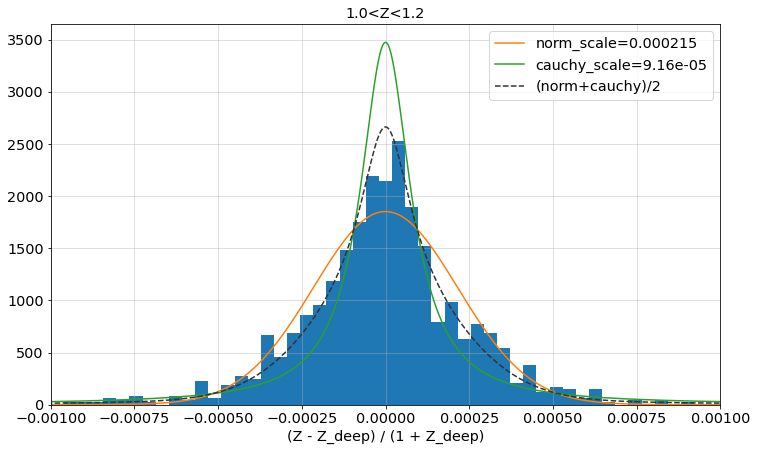

In [97]:
mask = (cat['Z']>1.) & (cat['Z']<1.2)
# dz = ((cat['Z']-cat['Z_deep']))[mask]
dz = ((cat['Z']-cat['Z_deep'])/(1+cat['Z_deep']))[mask]

bins_cdf = np.linspace(-0.002, 0.002, 1000)
bin_centers_cdf = (bins_cdf[1:] + bins_cdf[:-1])/2

count, _ =np.histogram(dz, bins=bins_cdf)
cdf = np.cumsum(count)
cdf = cdf/cdf.max()

popt = curve_fit(norm_cdf, bin_centers_cdf, cdf, p0=0.0004)
norm_scale = popt[0][0]
print(norm_scale)

popt = curve_fit(cauchy_cdf, bin_centers_cdf, cdf, p0=0.0002)
cauchy_scale = popt[0][0]
print(cauchy_scale)

# plt.figure(figsize=(12, 7))
# plt.plot(bin_centers_cdf, cdf)
# plt.plot(bin_centers_cdf, norm.cdf(bin_centers_cdf, scale=norm_scale), '--')
# plt.plot(bin_centers_cdf, cauchy.cdf(bin_centers_cdf, scale=cauchy_scale), '--')
# plt.grid(alpha=0.5)
# plt.show()

bins = np.linspace(-0.001, 0.001, 52)
plt.figure(figsize=(12, 7))
plt.hist(dz, log=False, bins=bins, density=True)
plt.xlabel('(Z - Z_deep) / (1 + Z_deep)')
plt.plot(bin_centers_cdf, norm.pdf(bin_centers_cdf, scale=norm_scale), label='norm_scale={:.3g}'.format(norm_scale))
plt.plot(bin_centers_cdf, cauchy.pdf(bin_centers_cdf, scale=cauchy_scale), label='cauchy_scale={:.3g}'.format(cauchy_scale))
plt.plot(bin_centers_cdf, (norm.pdf(bin_centers_cdf, scale=norm_scale)+cauchy.pdf(bin_centers_cdf, scale=cauchy_scale))/2, label='(norm+cauchy)/2'.format(cauchy_scale), ls='--', color='0.2')
plt.title('1.0<Z<1.2')
plt.xlim(-0.001, 0.001)
plt.grid(alpha=0.5)
plt.legend()
plt.show()

-------

2.010863716899464
0.9164116818615777


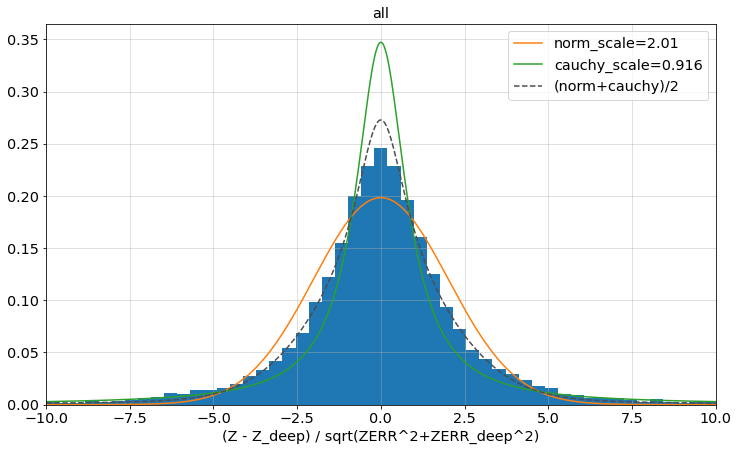

In [89]:
dz = ((cat['Z']-cat['Z_deep'])/np.sqrt(cat['ZERR']**2+cat['ZERR_deep']**2))

bins_cdf = np.linspace(-10, 10, 1000)
bin_centers_cdf = (bins_cdf[1:] + bins_cdf[:-1])/2

count, _ =np.histogram(dz, bins=bins_cdf)
cdf = np.cumsum(count)
cdf = cdf/cdf.max()

popt = curve_fit(norm_cdf, bin_centers_cdf, cdf, p0=1.)
norm_scale = popt[0][0]
print(norm_scale)

popt = curve_fit(cauchy_cdf, bin_centers_cdf, cdf, p0=1.)
cauchy_scale = popt[0][0]
print(cauchy_scale)

# plt.figure(figsize=(12, 7))
# plt.plot(bin_centers_cdf, cdf)
# plt.plot(bin_centers_cdf, norm.cdf(bin_centers_cdf, scale=norm_scale), '--')
# plt.plot(bin_centers_cdf, cauchy.cdf(bin_centers_cdf, scale=cauchy_scale), '--')
# plt.grid(alpha=0.5)
# plt.show()

bins = np.linspace(-10, 10, 52)
plt.figure(figsize=(12, 7))
plt.hist(dz, log=False, bins=bins, density=True)
plt.xlabel('(Z - Z_deep) / sqrt(ZERR^2+ZERR_deep^2)')
plt.plot(bin_centers_cdf, norm.pdf(bin_centers_cdf, scale=norm_scale), label='norm_scale={:.3g}'.format(norm_scale))
plt.plot(bin_centers_cdf, cauchy.pdf(bin_centers_cdf, scale=cauchy_scale), label='cauchy_scale={:.3g}'.format(cauchy_scale))
plt.plot(bin_centers_cdf, (norm.pdf(bin_centers_cdf, scale=norm_scale)+cauchy.pdf(bin_centers_cdf, scale=cauchy_scale))/2, label='(norm+cauchy)/2'.format(cauchy_scale), ls='--', color='0.3')
plt.title('all')
plt.xlim(-10, 10)
plt.grid(alpha=0.5)
plt.legend()
plt.show()

1.5500898224824653
0.6944770861791898


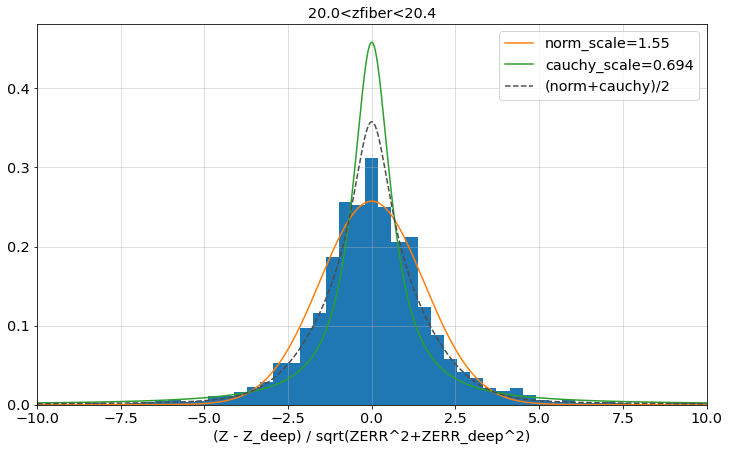

In [87]:
mask = (cat['zfibermag']>20.) & (cat['zfibermag']<20.4)
dz = ((cat['Z']-cat['Z_deep'])/np.sqrt(cat['ZERR']**2+cat['ZERR_deep']**2))[mask]

bins_cdf = np.linspace(-10, 10, 1000)
bin_centers_cdf = (bins_cdf[1:] + bins_cdf[:-1])/2

count, _ =np.histogram(dz, bins=bins_cdf)
cdf = np.cumsum(count)
cdf = cdf/cdf.max()

popt = curve_fit(norm_cdf, bin_centers_cdf, cdf, p0=1.)
norm_scale = popt[0][0]
print(norm_scale)

popt = curve_fit(cauchy_cdf, bin_centers_cdf, cdf, p0=1.)
cauchy_scale = popt[0][0]
print(cauchy_scale)

# plt.figure(figsize=(12, 7))
# plt.plot(bin_centers_cdf, cdf)
# plt.plot(bin_centers_cdf, norm.cdf(bin_centers_cdf, scale=norm_scale), '--')
# plt.plot(bin_centers_cdf, cauchy.cdf(bin_centers_cdf, scale=cauchy_scale), '--')
# plt.grid(alpha=0.5)
# plt.show()

bins = np.linspace(-10, 10, 52)
plt.figure(figsize=(12, 7))
plt.hist(dz, log=False, bins=bins, density=True)
plt.xlabel('(Z - Z_deep) / sqrt(ZERR^2+ZERR_deep^2)')
plt.plot(bin_centers_cdf, norm.pdf(bin_centers_cdf, scale=norm_scale), label='norm_scale={:.3g}'.format(norm_scale))
plt.plot(bin_centers_cdf, cauchy.pdf(bin_centers_cdf, scale=cauchy_scale), label='cauchy_scale={:.3g}'.format(cauchy_scale))
plt.plot(bin_centers_cdf, (norm.pdf(bin_centers_cdf, scale=norm_scale)+cauchy.pdf(bin_centers_cdf, scale=cauchy_scale))/2, label='(norm+cauchy)/2'.format(cauchy_scale), ls='--', color='0.3')
plt.title('20.0<zfiber<20.4')
plt.xlim(-10, 10)
plt.grid(alpha=0.5)
plt.legend()
plt.show()

2.0508813718233814
0.9398634839615024


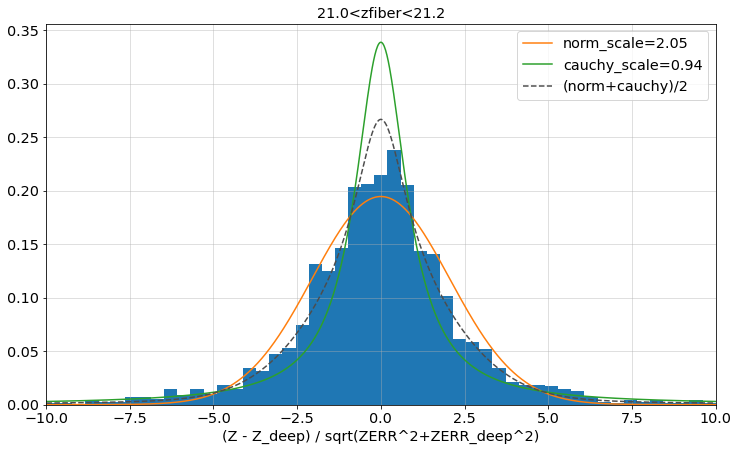

In [88]:
mask = (cat['zfibermag']>21) & (cat['zfibermag']<21.2)
dz = ((cat['Z']-cat['Z_deep'])/np.sqrt(cat['ZERR']**2+cat['ZERR_deep']**2))[mask]

bins_cdf = np.linspace(-10, 10, 1000)
bin_centers_cdf = (bins_cdf[1:] + bins_cdf[:-1])/2

count, _ =np.histogram(dz, bins=bins_cdf)
cdf = np.cumsum(count)
cdf = cdf/cdf.max()

popt = curve_fit(norm_cdf, bin_centers_cdf, cdf, p0=1.)
norm_scale = popt[0][0]
print(norm_scale)

popt = curve_fit(cauchy_cdf, bin_centers_cdf, cdf, p0=1.)
cauchy_scale = popt[0][0]
print(cauchy_scale)

# plt.figure(figsize=(12, 7))
# plt.plot(bin_centers_cdf, cdf)
# plt.plot(bin_centers_cdf, norm.cdf(bin_centers_cdf, scale=norm_scale), '--')
# plt.plot(bin_centers_cdf, cauchy.cdf(bin_centers_cdf, scale=cauchy_scale), '--')
# plt.grid(alpha=0.5)
# plt.show()

bins = np.linspace(-10, 10, 52)
plt.figure(figsize=(12, 7))
plt.hist(dz, log=False, bins=bins, density=True)
plt.xlabel('(Z - Z_deep) / sqrt(ZERR^2+ZERR_deep^2)')
plt.plot(bin_centers_cdf, norm.pdf(bin_centers_cdf, scale=norm_scale), label='norm_scale={:.3g}'.format(norm_scale))
plt.plot(bin_centers_cdf, cauchy.pdf(bin_centers_cdf, scale=cauchy_scale), label='cauchy_scale={:.3g}'.format(cauchy_scale))
plt.plot(bin_centers_cdf, (norm.pdf(bin_centers_cdf, scale=norm_scale)+cauchy.pdf(bin_centers_cdf, scale=cauchy_scale))/2, label='(norm+cauchy)/2'.format(cauchy_scale), ls='--', color='0.3')
plt.title('21.0<zfiber<21.2')
plt.xlim(-10, 10)
plt.grid(alpha=0.5)
plt.legend()
plt.show()

2.6590757306671526
1.2320949912991357


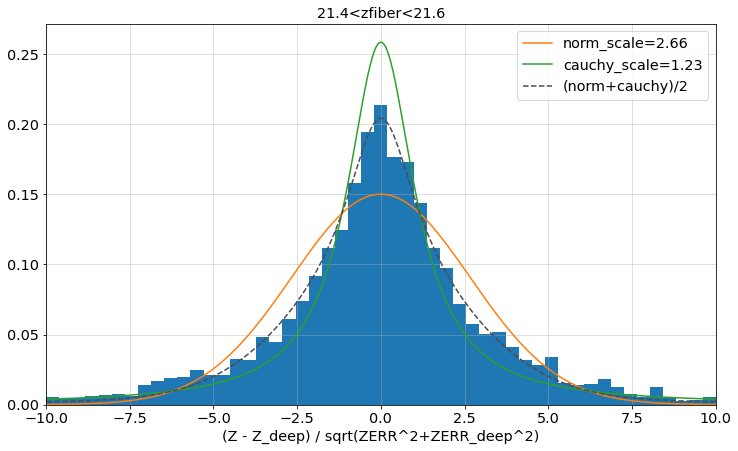

In [84]:
mask = (cat['zfibermag']>21.4) & (cat['zfibermag']<21.6)
dz = ((cat['Z']-cat['Z_deep'])/np.sqrt(cat['ZERR']**2+cat['ZERR_deep']**2))[mask]

bins_cdf = np.linspace(-10, 10, 1000)
bin_centers_cdf = (bins_cdf[1:] + bins_cdf[:-1])/2

count, _ =np.histogram(dz, bins=bins_cdf)
cdf = np.cumsum(count)
cdf = cdf/cdf.max()

popt = curve_fit(norm_cdf, bin_centers_cdf, cdf, p0=1.)
norm_scale = popt[0][0]
print(norm_scale)

popt = curve_fit(cauchy_cdf, bin_centers_cdf, cdf, p0=1.)
cauchy_scale = popt[0][0]
print(cauchy_scale)

# plt.figure(figsize=(12, 7))
# plt.plot(bin_centers_cdf, cdf)
# plt.plot(bin_centers_cdf, norm.cdf(bin_centers_cdf, scale=norm_scale), '--')
# plt.plot(bin_centers_cdf, cauchy.cdf(bin_centers_cdf, scale=cauchy_scale), '--')
# plt.grid(alpha=0.5)
# plt.show()

bins = np.linspace(-10, 10, 52)
plt.figure(figsize=(12, 7))
plt.hist(dz, log=False, bins=bins, density=True)
plt.xlabel('(Z - Z_deep) / sqrt(ZERR^2+ZERR_deep^2)')
plt.plot(bin_centers_cdf, norm.pdf(bin_centers_cdf, scale=norm_scale), label='norm_scale={:.3g}'.format(norm_scale))
plt.plot(bin_centers_cdf, cauchy.pdf(bin_centers_cdf, scale=cauchy_scale), label='cauchy_scale={:.3g}'.format(cauchy_scale))
plt.plot(bin_centers_cdf, (norm.pdf(bin_centers_cdf, scale=norm_scale)+cauchy.pdf(bin_centers_cdf, scale=cauchy_scale))/2, label='(norm+cauchy)/2'.format(cauchy_scale), ls='--', color='0.3')
plt.title('21.4<zfiber<21.6')
plt.xlim(-10, 10)
plt.grid(alpha=0.5)
plt.legend()
plt.show()

-------

1.5662729125687276
0.7019487102435302


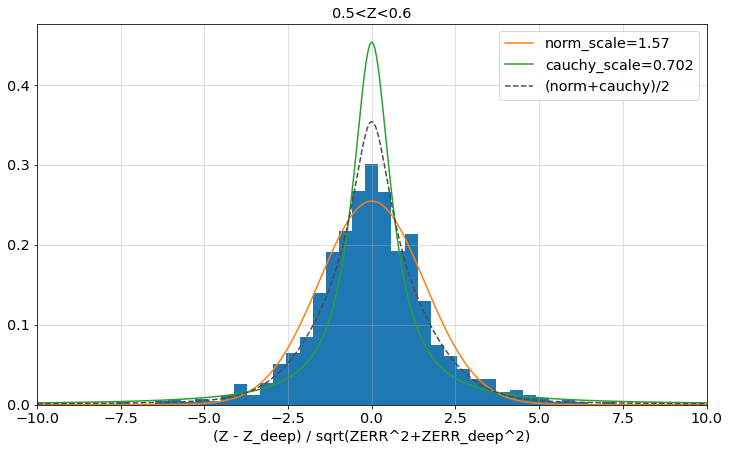

In [98]:
mask = (cat['Z']>0.5) & (cat['Z']<0.6)
dz = ((cat['Z']-cat['Z_deep'])/np.sqrt(cat['ZERR']**2+cat['ZERR_deep']**2))[mask]

bins_cdf = np.linspace(-10, 10, 1000)
bin_centers_cdf = (bins_cdf[1:] + bins_cdf[:-1])/2

count, _ =np.histogram(dz, bins=bins_cdf)
cdf = np.cumsum(count)
cdf = cdf/cdf.max()

popt = curve_fit(norm_cdf, bin_centers_cdf, cdf, p0=1.)
norm_scale = popt[0][0]
print(norm_scale)

popt = curve_fit(cauchy_cdf, bin_centers_cdf, cdf, p0=1.)
cauchy_scale = popt[0][0]
print(cauchy_scale)

# plt.figure(figsize=(12, 7))
# plt.plot(bin_centers_cdf, cdf)
# plt.plot(bin_centers_cdf, norm.cdf(bin_centers_cdf, scale=norm_scale), '--')
# plt.plot(bin_centers_cdf, cauchy.cdf(bin_centers_cdf, scale=cauchy_scale), '--')
# plt.grid(alpha=0.5)
# plt.show()

bins = np.linspace(-10, 10, 52)
plt.figure(figsize=(12, 7))
plt.hist(dz, log=False, bins=bins, density=True)
plt.xlabel('(Z - Z_deep) / sqrt(ZERR^2+ZERR_deep^2)')
plt.plot(bin_centers_cdf, norm.pdf(bin_centers_cdf, scale=norm_scale), label='norm_scale={:.3g}'.format(norm_scale))
plt.plot(bin_centers_cdf, cauchy.pdf(bin_centers_cdf, scale=cauchy_scale), label='cauchy_scale={:.3g}'.format(cauchy_scale))
plt.plot(bin_centers_cdf, (norm.pdf(bin_centers_cdf, scale=norm_scale)+cauchy.pdf(bin_centers_cdf, scale=cauchy_scale))/2, label='(norm+cauchy)/2'.format(cauchy_scale), ls='--', color='0.3')
plt.title('0.5<Z<0.6')
plt.xlim(-10, 10)
plt.grid(alpha=0.5)
plt.legend()
plt.show()

2.3748195889959893
1.0881192886505788


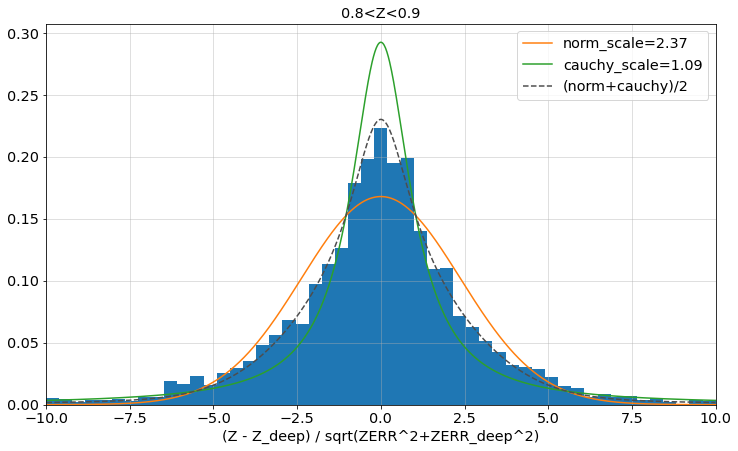

In [100]:
mask = (cat['Z']>0.8) & (cat['Z']<0.9)
dz = ((cat['Z']-cat['Z_deep'])/np.sqrt(cat['ZERR']**2+cat['ZERR_deep']**2))[mask]

bins_cdf = np.linspace(-10, 10, 1000)
bin_centers_cdf = (bins_cdf[1:] + bins_cdf[:-1])/2

count, _ =np.histogram(dz, bins=bins_cdf)
cdf = np.cumsum(count)
cdf = cdf/cdf.max()

popt = curve_fit(norm_cdf, bin_centers_cdf, cdf, p0=1.)
norm_scale = popt[0][0]
print(norm_scale)

popt = curve_fit(cauchy_cdf, bin_centers_cdf, cdf, p0=1.)
cauchy_scale = popt[0][0]
print(cauchy_scale)

# plt.figure(figsize=(12, 7))
# plt.plot(bin_centers_cdf, cdf)
# plt.plot(bin_centers_cdf, norm.cdf(bin_centers_cdf, scale=norm_scale), '--')
# plt.plot(bin_centers_cdf, cauchy.cdf(bin_centers_cdf, scale=cauchy_scale), '--')
# plt.grid(alpha=0.5)
# plt.show()

bins = np.linspace(-10, 10, 52)
plt.figure(figsize=(12, 7))
plt.hist(dz, log=False, bins=bins, density=True)
plt.xlabel('(Z - Z_deep) / sqrt(ZERR^2+ZERR_deep^2)')
plt.plot(bin_centers_cdf, norm.pdf(bin_centers_cdf, scale=norm_scale), label='norm_scale={:.3g}'.format(norm_scale))
plt.plot(bin_centers_cdf, cauchy.pdf(bin_centers_cdf, scale=cauchy_scale), label='cauchy_scale={:.3g}'.format(cauchy_scale))
plt.plot(bin_centers_cdf, (norm.pdf(bin_centers_cdf, scale=norm_scale)+cauchy.pdf(bin_centers_cdf, scale=cauchy_scale))/2, label='(norm+cauchy)/2'.format(cauchy_scale), ls='--', color='0.3')
plt.title('0.8<Z<0.9')
plt.xlim(-10, 10)
plt.grid(alpha=0.5)
plt.legend()
plt.show()

2.587578684524963
1.1963017301516543


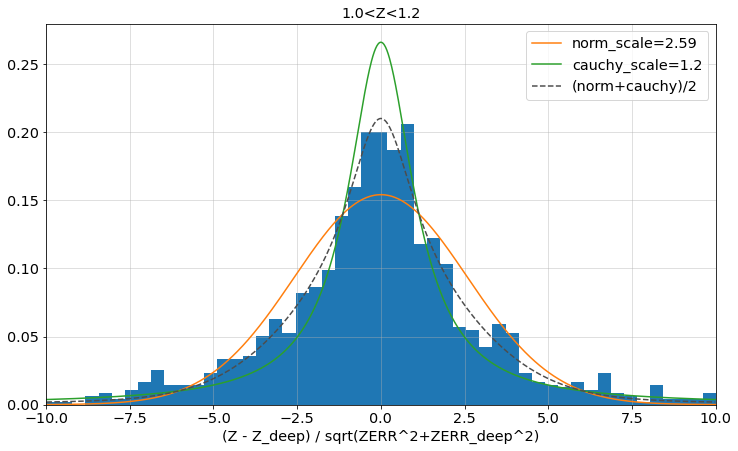

In [99]:
mask = (cat['Z']>1.0) & (cat['Z']<1.2)
dz = ((cat['Z']-cat['Z_deep'])/np.sqrt(cat['ZERR']**2+cat['ZERR_deep']**2))[mask]

bins_cdf = np.linspace(-10, 10, 1000)
bin_centers_cdf = (bins_cdf[1:] + bins_cdf[:-1])/2

count, _ =np.histogram(dz, bins=bins_cdf)
cdf = np.cumsum(count)
cdf = cdf/cdf.max()

popt = curve_fit(norm_cdf, bin_centers_cdf, cdf, p0=1.)
norm_scale = popt[0][0]
print(norm_scale)

popt = curve_fit(cauchy_cdf, bin_centers_cdf, cdf, p0=1.)
cauchy_scale = popt[0][0]
print(cauchy_scale)

# plt.figure(figsize=(12, 7))
# plt.plot(bin_centers_cdf, cdf)
# plt.plot(bin_centers_cdf, norm.cdf(bin_centers_cdf, scale=norm_scale), '--')
# plt.plot(bin_centers_cdf, cauchy.cdf(bin_centers_cdf, scale=cauchy_scale), '--')
# plt.grid(alpha=0.5)
# plt.show()

bins = np.linspace(-10, 10, 52)
plt.figure(figsize=(12, 7))
plt.hist(dz, log=False, bins=bins, density=True)
plt.xlabel('(Z - Z_deep) / sqrt(ZERR^2+ZERR_deep^2)')
plt.plot(bin_centers_cdf, norm.pdf(bin_centers_cdf, scale=norm_scale), label='norm_scale={:.3g}'.format(norm_scale))
plt.plot(bin_centers_cdf, cauchy.pdf(bin_centers_cdf, scale=cauchy_scale), label='cauchy_scale={:.3g}'.format(cauchy_scale))
plt.plot(bin_centers_cdf, (norm.pdf(bin_centers_cdf, scale=norm_scale)+cauchy.pdf(bin_centers_cdf, scale=cauchy_scale))/2, label='(norm+cauchy)/2'.format(cauchy_scale), ls='--', color='0.3')
plt.title('1.0<Z<1.2')
plt.xlim(-10, 10)
plt.grid(alpha=0.5)
plt.legend()
plt.show()